# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



---

### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

> **Answer**: The dataset covers **17 marketing campaigns**. It contains records from a Portuguese banking institution covering **17 marketing campaigns** conducted between **May 2008 and November 2010**.

---

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [1]:
import pandas as pd
import numpy as np
import time
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import LinearSVC, SVC
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve
)

# Global plot style
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (8, 5)})
RANDOM_STATE = 42

print('All libraries loaded successfully.')

All libraries loaded successfully.


In [2]:
bank_df = pd.read_csv('data/bank-additional-full.csv', sep=';')

print(f'Dataset shape: {bank_df.shape}')
print(f'Rows: {bank_df.shape[0]:,}  |  Columns: {bank_df.shape[1]}')

Dataset shape: (41188, 21)
Rows: 41,188  |  Columns: 21


In [3]:
bank_df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


---

### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



In [4]:
# Data types and non-null counts
print('=== DataFrame Info ===')
bank_df.info()
print()

# Check for explicit null values
print('=== Missing Values per Column ===')
print(bank_df.isnull().sum())

=== DataFrame Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.con

In [5]:
# Check for 'unknown' strings (encoded missing values)
print('=== Count of "unknown" per Categorical Column ===')
cat_cols_all = bank_df.select_dtypes(include='object').columns
unknown_counts = {col: (bank_df[col] == 'unknown').sum() for col in cat_cols_all}
unknown_df = pd.Series(unknown_counts).rename('unknown_count').to_frame()
unknown_df['pct_of_rows'] = (unknown_df['unknown_count'] / len(bank_df) * 100).round(2)
print(unknown_df[unknown_df['unknown_count'] > 0])

=== Count of "unknown" per Categorical Column ===
           unknown_count  pct_of_rows
job                  330         0.80
marital               80         0.19
education           1731         4.20
default             8597        20.87
housing              990         2.40
loan                 990         2.40


In [6]:
# Descriptive statistics for numeric features
print('=== Numeric Feature Statistics ===')
bank_df.describe().T.round(2)

=== Numeric Feature Statistics ===


,count,mean,std,min,25%,50%,75%,max
age,41188.0,40.02,10.42,17.00,32.00,38.00,47.00,98.00
duration,41188.0,258.29,259.28,0.00,102.00,180.00,319.00,4918.00
campaign,41188.0,2.57,2.77,1.00,1.00,2.00,3.00,56.00
pdays,41188.0,962.48,186.91,0.00,999.00,999.00,999.00,999.00
previous,41188.0,0.17,0.49,0.00,0.00,0.00,0.00,7.00
emp.var.rate,41188.0,0.08,1.57,-3.40,-1.80,1.10,1.40,1.40
cons.price.idx,41188.0,93.58,0.58,92.20,93.08,93.75,93.99,94.77
cons.conf.idx,41188.0,-40.50,4.63,-50.80,-42.70,-41.80,-36.40,-26.90
euribor3m,41188.0,3.62,1.73,0.63,1.34,4.86,4.96,5.04
nr.employed,41188.0,5167.04,72.25,4963.60,5099.10,5191.00,5228.10,5228.10


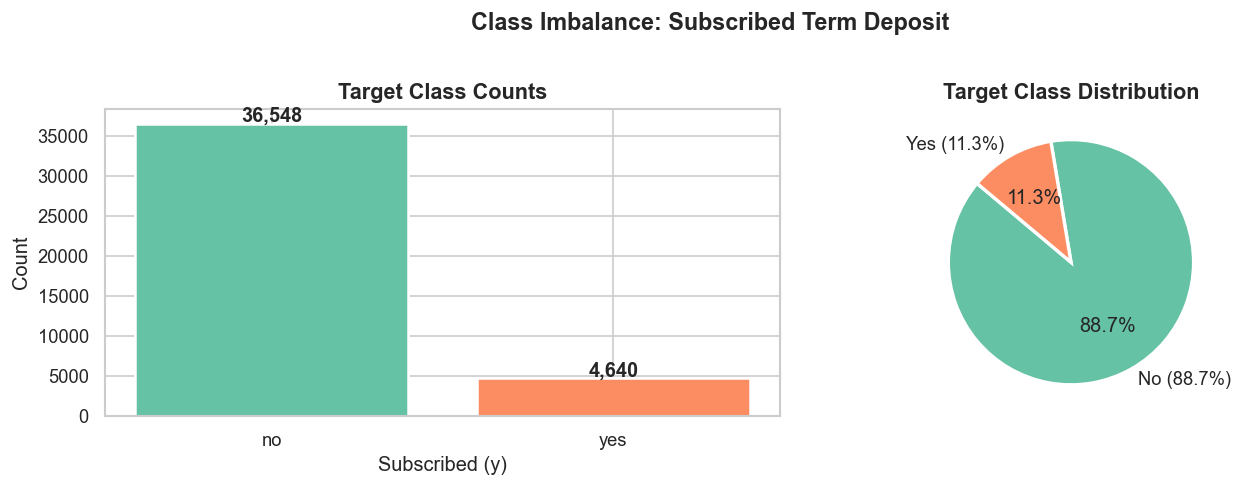


Class distribution:
y
no     88.7
yes    11.3%


In [7]:
# Target class distribution
target_counts = bank_df['y'].value_counts()
target_pct = bank_df['y'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(target_counts.index, target_counts.values, color=['#66c2a5', '#fc8d62'], 
            edgecolor='white', linewidth=1.5)
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontweight='bold')
axes[0].set_title('Target Class Counts', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Subscribed (y)')
axes[0].set_ylabel('Count')

axes[1].pie(target_counts.values, labels=['No (88.7%)', 'Yes (11.3%)'],
            colors=['#66c2a5', '#fc8d62'], autopct='%1.1f%%',
            startangle=140, wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Target Class Distribution', fontsize=13, fontweight='bold')

plt.suptitle('Class Imbalance: Subscribed Term Deposit', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('images\class_distribution.png', bbox_inches='tight')
plt.show()
print(f"\nClass distribution:\n{target_pct.round(1).to_string()}%")

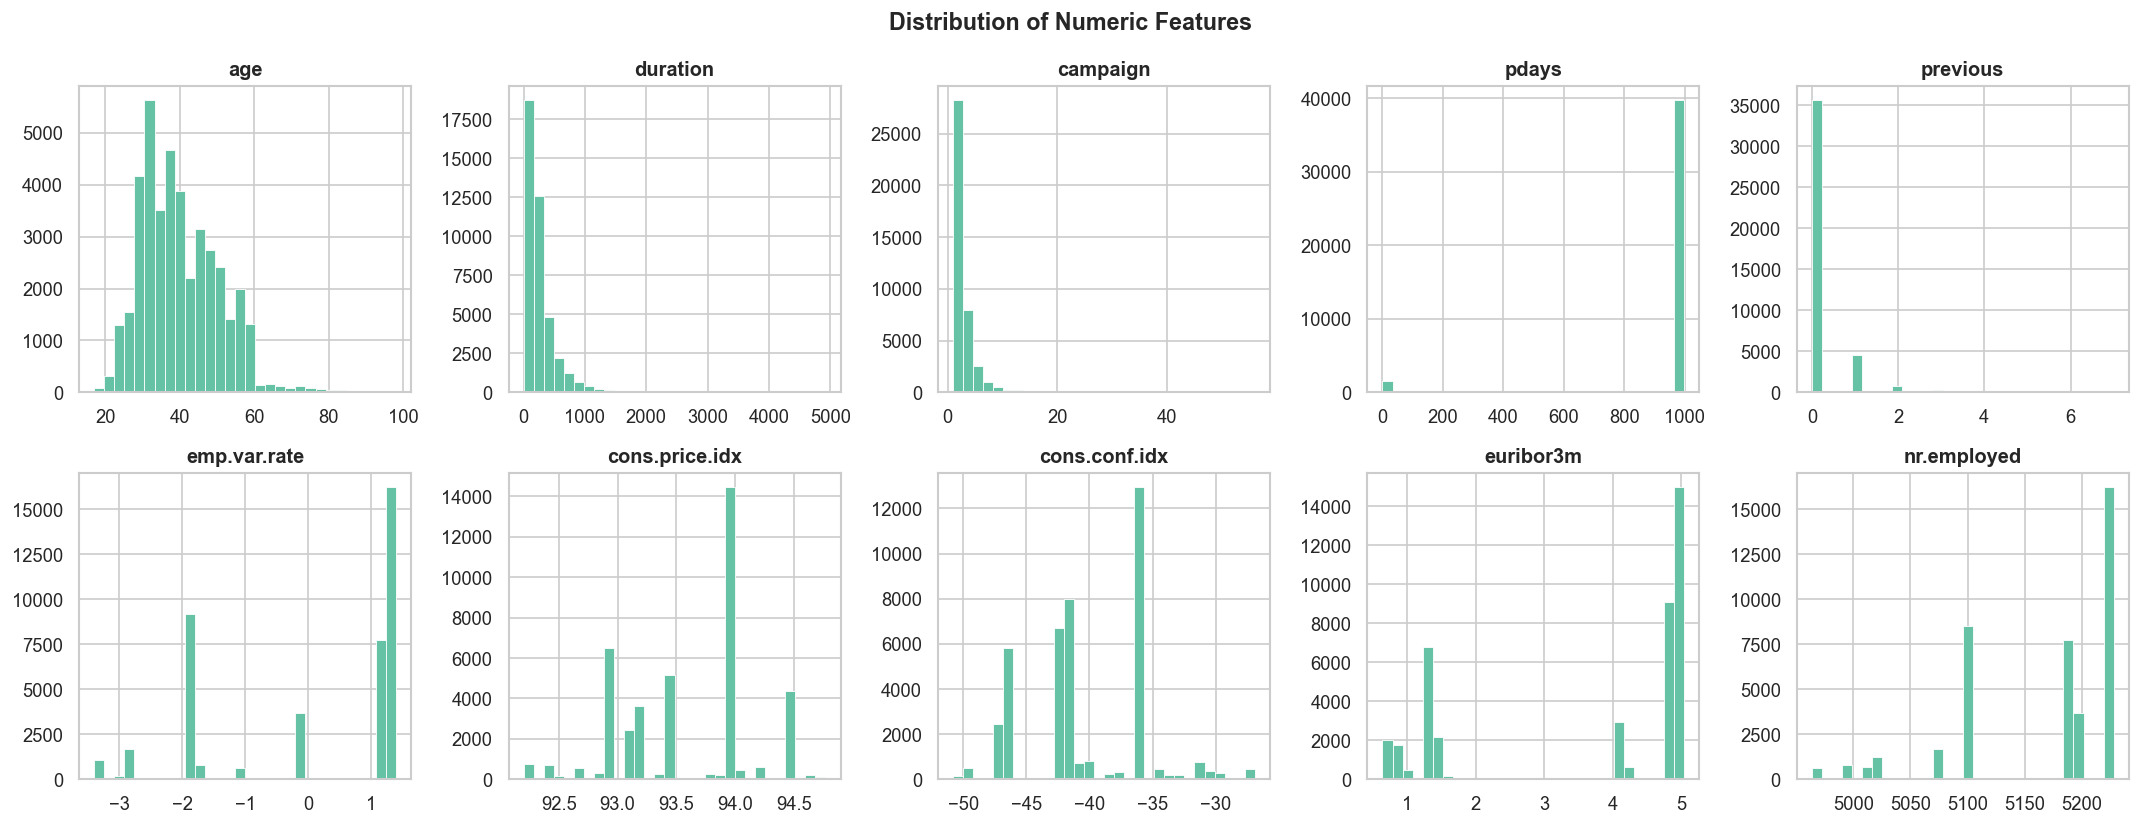

In [8]:
# Distribution of numeric features
num_features = ['age', 'duration', 'campaign', 'pdays', 'previous',
                 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()

for i, feat in enumerate(num_features):
    axes[i].hist(bank_df[feat], bins=30, color='#66c2a5', edgecolor='white', linewidth=0.5)
    axes[i].set_title(feat, fontweight='bold')
    axes[i].set_xlabel('')

plt.suptitle('Distribution of Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images\\numeric_distributions.png', bbox_inches='tight')
plt.show()

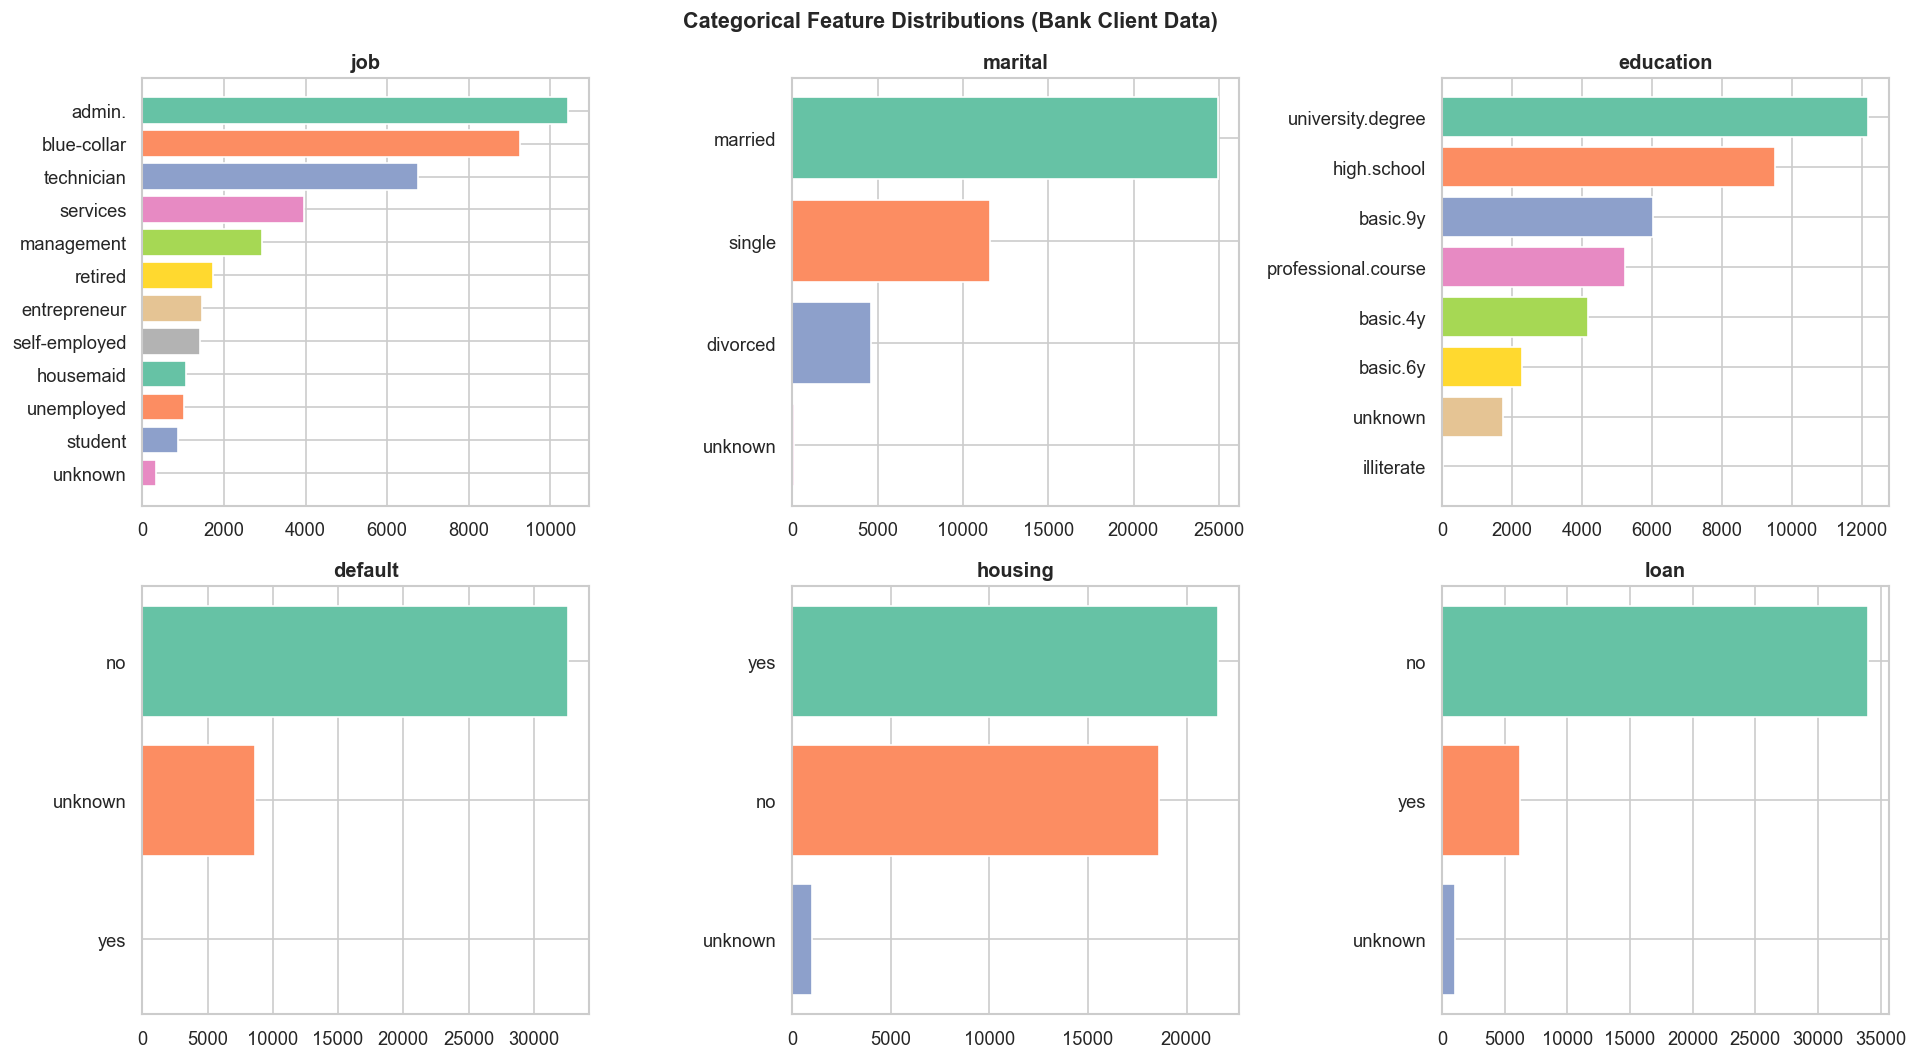

In [9]:
# Categorical feature value counts for bank client features
cat_bank_feats = ['job', 'marital', 'education', 'default', 'housing', 'loan']
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, feat in enumerate(cat_bank_feats):
    counts = bank_df[feat].value_counts()
    axes[i].barh(counts.index, counts.values, color=sns.color_palette('Set2', len(counts)))
    axes[i].set_title(feat, fontweight='bold')
    axes[i].invert_yaxis()

plt.suptitle('Categorical Feature Distributions (Bank Client Data)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('images\categorical_distributions.png', bbox_inches='tight')
plt.show()

**Key Observations from Feature Exploration:**
- **No explicit missing values** (NaN) exist in any column.
- Several categorical features use **`'unknown'`** as an encoded missing value: `job` (0.8%), `marital` (0.2%), `education` (4.2%), `default` (20.9%), `housing` (2.4%), `loan` (2.4%). The `default` column has the highest ambiguity but is retained since removing 20% of data would be costly.
- The **target variable is highly imbalanced** — only ~11.3% of contacts resulted in a subscription. This means accuracy alone is a misleading metric.
- `pdays = 999` indicates a client was **never previously contacted** (a sentinel value, not a real day count).
- `duration` (call duration) is a data-leakage risk and will be excluded from the predictive model features.

---

### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

**Business Objective:**

> Build a **binary classification model** that predicts whether a bank client will subscribe to a **term deposit** (`y = 'yes'`) based on their demographic and banking profile, collected prior to or during a telephone marketing campaign.

**Why this matters:**
- Telemarketing campaigns are resource-intensive. Accurately identifying clients likely to subscribe allows the bank to **prioritize outreach**, **reduce wasted calls**, and **increase conversion rates**.
- The model must handle significant **class imbalance** (~88.7% No / ~11.3% Yes), so precision and recall on the minority class ("yes") are as important as overall accuracy.
- A good model should outperform the **naive baseline** of always predicting "No" (88.7% accuracy).

---

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

We use only the **bank client information features** (age, job, marital, education, default, housing, loan) as specified. `duration` is excluded to avoid data leakage.

In [10]:
# Define feature sets
BANK_CLIENT_FEATURES = ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan']
TARGET = 'y'

NUMERIC_FEATURES = ['age']
CATEGORICAL_FEATURES = ['job', 'marital', 'education', 'default', 'housing', 'loan']

# Prepare X and y
X = bank_df[BANK_CLIENT_FEATURES].copy()
y = (bank_df[TARGET] == 'yes').astype(int)  # Binary encode: yes=1, no=0

print(f'Feature matrix shape: {X.shape}')
print(f'Target distribution:\n  No  (0): {(y==0).sum():,} ({(y==0).mean()*100:.1f}%)')
print(f'  Yes (1): {(y==1).sum():,} ({(y==1).mean()*100:.1f}%)')
X.head()

Feature matrix shape: (41188, 7)
Target distribution:
  No  (0): 36,548 (88.7%)
  Yes (1): 4,640 (11.3%)


,age,job,marital,education,default,housing,loan
0,56,housemaid,married,basic.4y,no,no,no
1,57,services,married,high.school,unknown,no,no
2,37,services,married,high.school,no,yes,no
3,40,admin.,married,basic.6y,no,no,no
4,56,services,married,high.school,no,no,yes


In [11]:
# Build preprocessing pipeline
# - Numeric: StandardScaler
# - Categorical: OneHotEncoder (drop='first' to avoid multicollinearity)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), NUMERIC_FEATURES),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), CATEGORICAL_FEATURES)
    ],
    remainder='drop'
)

# Fit and inspect transformed feature names
X_transformed_sample = preprocessor.fit_transform(X)
cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(CATEGORICAL_FEATURES)
all_feature_names = NUMERIC_FEATURES + list(cat_feature_names)

print(f'Original features:    {X.shape[1]}')
print(f'Transformed features: {X_transformed_sample.shape[1]}')
print(f'\nEncoded feature names:\n{all_feature_names}')

Original features:    7
Transformed features: 28

Encoded feature names:
['age', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'job_unknown', 'marital_married', 'marital_single', 'marital_unknown', 'education_basic.6y', 'education_basic.9y', 'education_high.school', 'education_illiterate', 'education_professional.course', 'education_university.degree', 'education_unknown', 'default_unknown', 'default_yes', 'housing_unknown', 'housing_yes', 'loan_unknown', 'loan_yes']


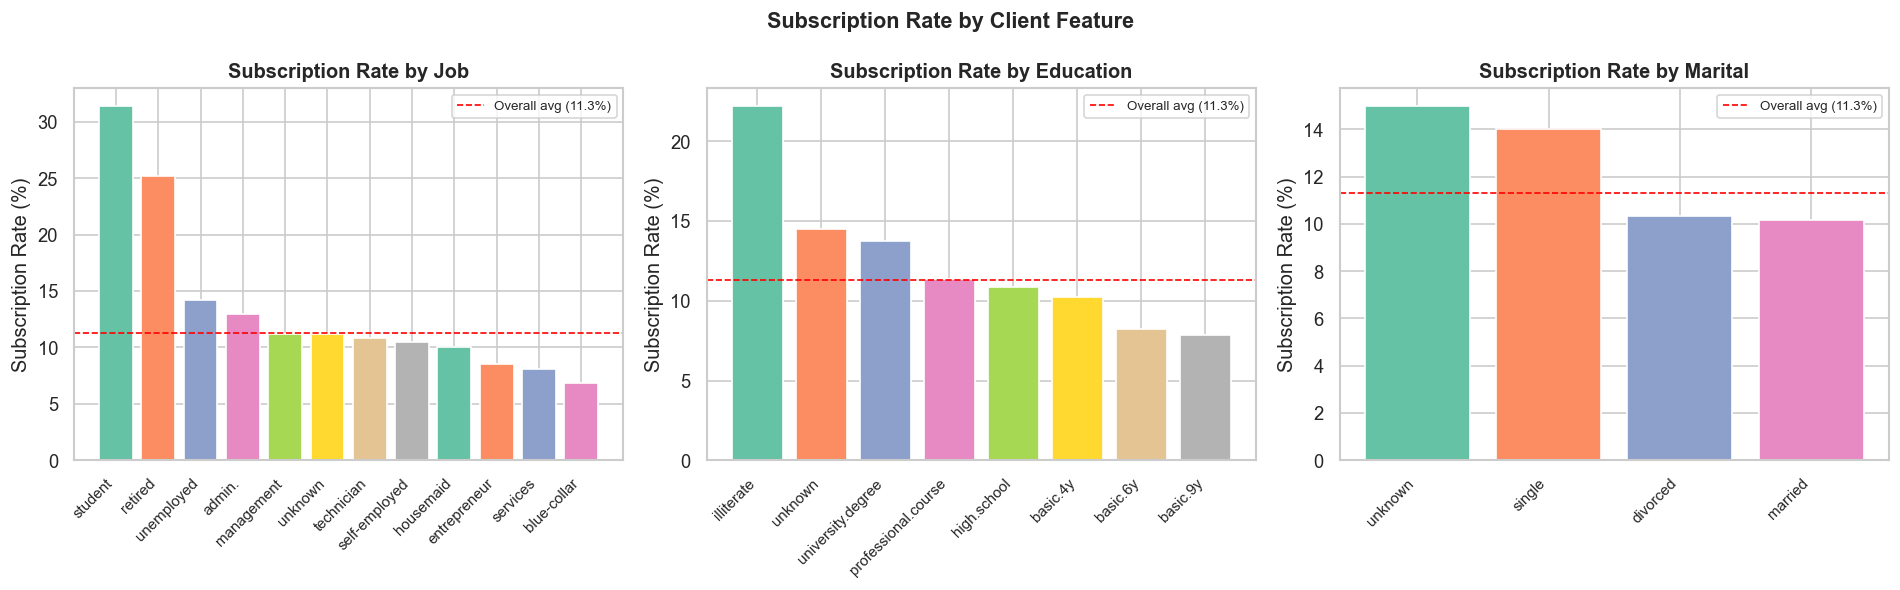

In [12]:
# Visualize subscription rate by key categorical features
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, feat in zip(axes, ['job', 'education', 'marital']):
    rates = bank_df.groupby(feat)['y'].apply(lambda x: (x=='yes').mean() * 100).sort_values(ascending=False)
    ax.bar(range(len(rates)), rates.values, color=sns.color_palette('Set2', len(rates)))
    ax.set_xticks(range(len(rates)))
    ax.set_xticklabels(rates.index, rotation=45, ha='right', fontsize=9)
    ax.set_title(f'Subscription Rate by {feat.capitalize()}', fontweight='bold')
    ax.set_ylabel('Subscription Rate (%)')
    ax.axhline(y=11.3, color='red', linestyle='--', linewidth=1, label='Overall avg (11.3%)')
    ax.legend(fontsize=8)

plt.suptitle('Subscription Rate by Client Feature', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('images\subscription_rates.png', bbox_inches='tight')
plt.show()

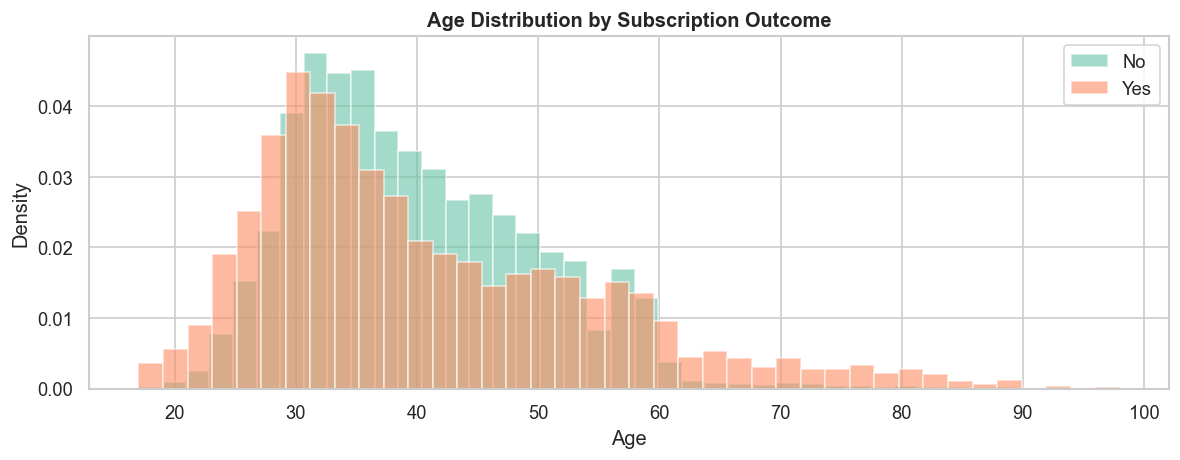

In [13]:
# Age distribution by subscription outcome
fig, ax = plt.subplots(figsize=(10, 4))
bank_df[bank_df['y']=='no']['age'].hist(bins=40, alpha=0.6, label='No', color='#66c2a5', ax=ax, density=True)
bank_df[bank_df['y']=='yes']['age'].hist(bins=40, alpha=0.6, label='Yes', color='#fc8d62', ax=ax, density=True)
ax.set_title('Age Distribution by Subscription Outcome', fontweight='bold')
ax.set_xlabel('Age')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.savefig('images\\age_distribution.png', bbox_inches='tight')
plt.show()

---

### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [14]:
# Stratified split to preserve class proportions
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y  # preserve class balance in both sets
)

print('=== Train/Test Split Summary ===')
print(f'Training set:  {X_train.shape[0]:,} rows  ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Test set:      {X_test.shape[0]:,} rows  ({X_test.shape[0]/len(X)*100:.0f}%)')
print()
print(f'Train class balance — No: {(y_train==0).sum():,} | Yes: {(y_train==1).sum():,}')
print(f'Test  class balance — No: {(y_test==0).sum():,}  | Yes: {(y_test==1).sum():,}')

=== Train/Test Split Summary ===
Training set:  32,950 rows  (80%)
Test set:      8,238 rows  (20%)

Train class balance — No: 29,238 | Yes: 3,712
Test  class balance — No: 7,310  | Yes: 928


---

### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

Before fitting any classifier, we establish a **naive baseline** using the most-frequent-class strategy — always predict "No" (0). This gives us a floor that all real models must beat.

In [15]:
dummy_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE))
])
dummy_pipe.fit(X_train, y_train)
baseline_acc = dummy_pipe.score(X_test, y_test)

print(f'Baseline Accuracy (always predict "No"): {baseline_acc:.4f} ({baseline_acc*100:.1f}%)')
print()
print('Baseline Classification Report:')
print(classification_report(y_test, dummy_pipe.predict(X_test), target_names=['No', 'Yes']))

Baseline Accuracy (always predict "No"): 0.8874 (88.7%)

Baseline Classification Report:
              precision    recall  f1-score   support

          No       0.89      1.00      0.94      7310
         Yes       0.00      0.00      0.00       928

    accuracy                           0.89      8238
   macro avg       0.44      0.50      0.47      8238
weighted avg       0.79      0.89      0.83      8238



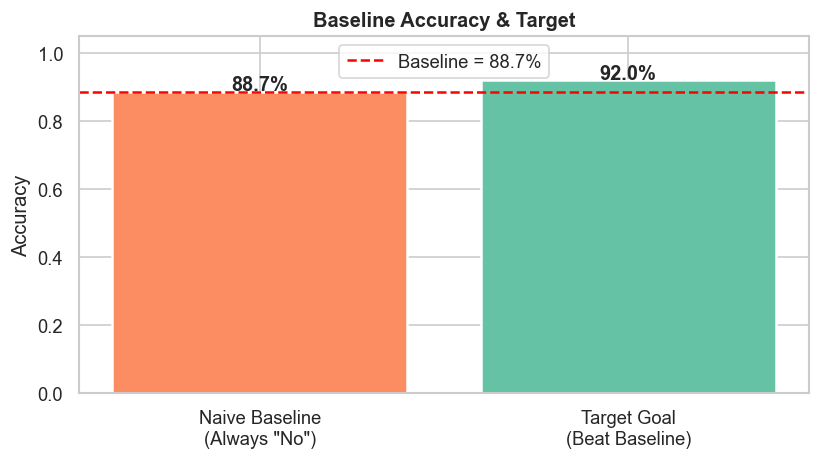


Any model must beat 88.7% accuracy AND show meaningful recall for the "Yes" class.


In [16]:
# Visualize baseline vs realistic target
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(['Naive Baseline\n(Always "No")', 'Target Goal\n(Beat Baseline)'],
               [baseline_acc, 0.92], color=['#fc8d62', '#66c2a5'], edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, [baseline_acc, 0.92]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val*100:.1f}%', ha='center', fontweight='bold', fontsize=12)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Accuracy')
ax.set_title('Baseline Accuracy & Target', fontweight='bold')
ax.axhline(y=baseline_acc, color='red', linestyle='--', linewidth=1.5, label=f'Baseline = {baseline_acc*100:.1f}%')
ax.legend()
plt.tight_layout()
plt.savefig('images\\baseline.png', bbox_inches='tight')
plt.show()

print(f'\nAny model must beat {baseline_acc*100:.1f}% accuracy AND show meaningful recall for the "Yes" class.')

---

### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [17]:
lr_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

t0 = time.time()
lr_pipe.fit(X_train, y_train)
lr_train_time = time.time() - t0

lr_train_acc = lr_pipe.score(X_train, y_train)
lr_test_acc  = lr_pipe.score(X_test,  y_test)

print(f'Logistic Regression')
print(f'  Train Accuracy : {lr_train_acc:.4f}')
print(f'  Test  Accuracy : {lr_test_acc:.4f}')
print(f'  Train Time     : {lr_train_time:.3f}s')

Logistic Regression
  Train Accuracy : 0.8873
  Test  Accuracy : 0.8874
  Train Time     : 0.165s


---

### Problem 9: Score the Model

What is the accuracy of your model?

In [18]:
y_pred_lr = lr_pipe.predict(X_test)
y_prob_lr = lr_pipe.predict_proba(X_test)[:, 1]

print('=== Logistic Regression — Full Evaluation ===')
print(f'Accuracy : {accuracy_score(y_test, y_pred_lr):.4f}')
print(f'ROC-AUC  : {roc_auc_score(y_test, y_prob_lr):.4f}')
print()
print(classification_report(y_test, y_pred_lr, target_names=['No (0)', 'Yes (1)']))

=== Logistic Regression — Full Evaluation ===
Accuracy : 0.8874
ROC-AUC  : 0.6493

              precision    recall  f1-score   support

      No (0)       0.89      1.00      0.94      7310
     Yes (1)       0.00      0.00      0.00       928

    accuracy                           0.89      8238
   macro avg       0.44      0.50      0.47      8238
weighted avg       0.79      0.89      0.83      8238



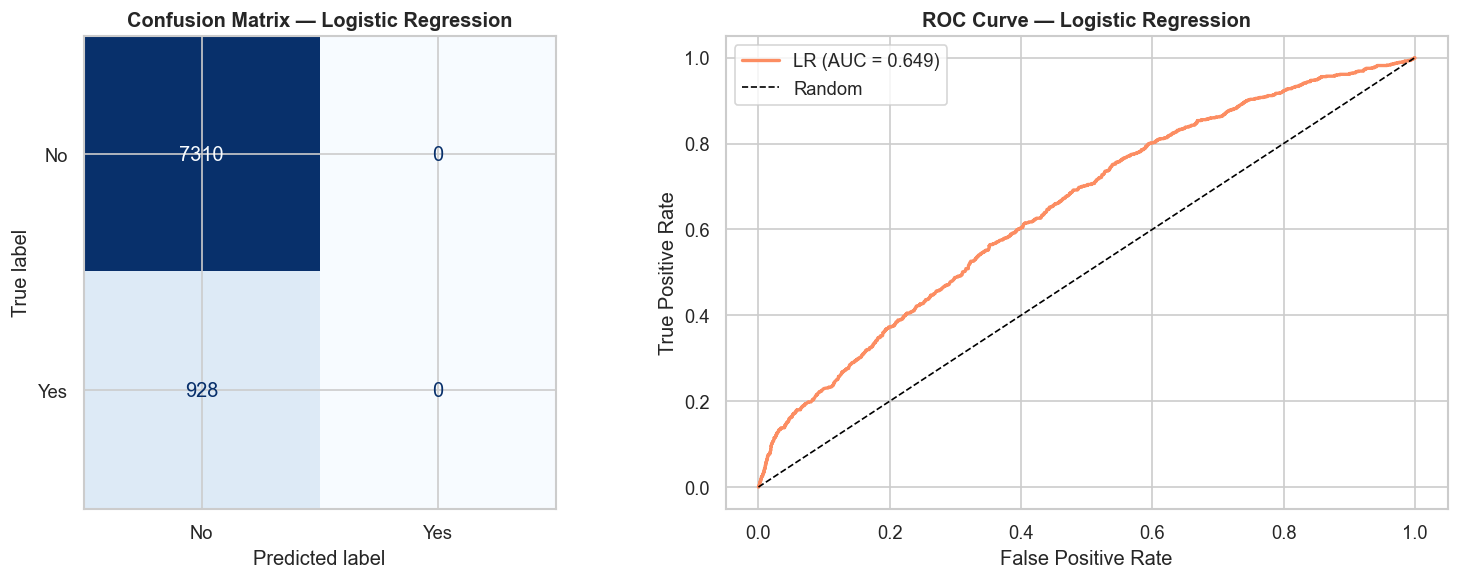

In [19]:
# Confusion matrix & ROC curve for Logistic Regression
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix — Logistic Regression', fontweight='bold')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_lr)
auc_score = roc_auc_score(y_test, y_prob_lr)
axes[1].plot(fpr, tpr, color='#fc8d62', lw=2, label=f'LR (AUC = {auc_score:.3f})')
axes[1].plot([0,1],[0,1], 'k--', lw=1, label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — Logistic Regression', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('images\lr_evaluation.png', bbox_inches='tight')
plt.show()

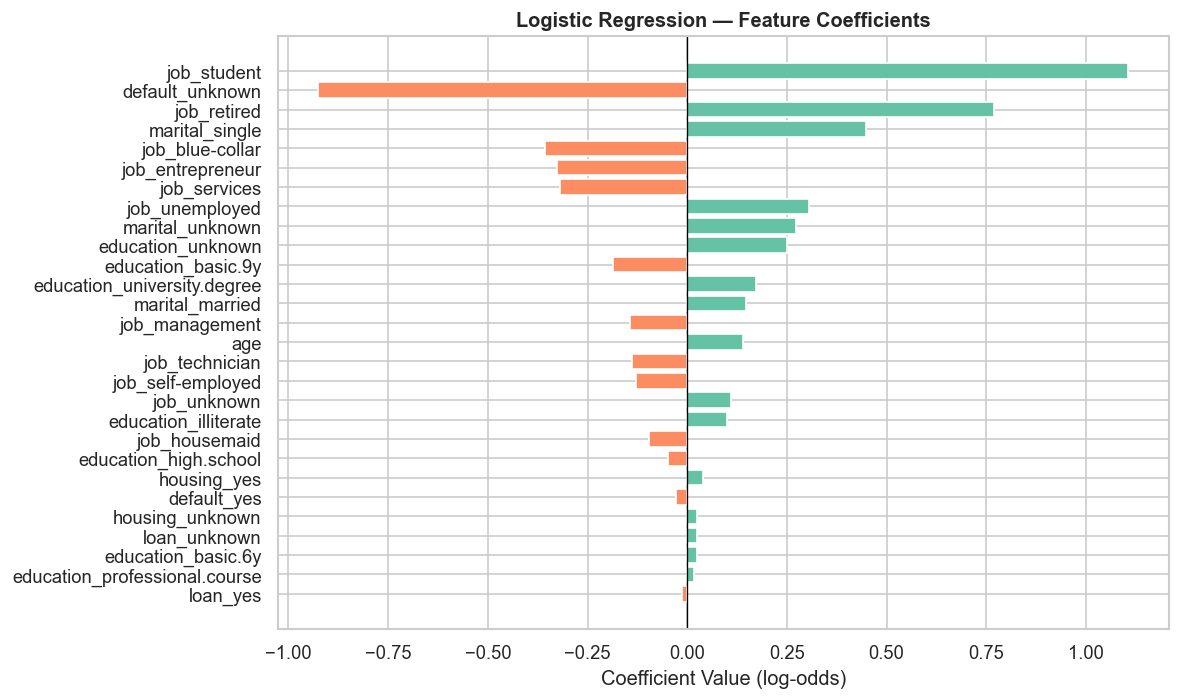

In [20]:
# Logistic Regression — Feature Coefficients
lr_coefs = lr_pipe.named_steps['clf'].coef_[0]
coef_df = pd.DataFrame({'Feature': all_feature_names, 'Coefficient': lr_coefs})
coef_df = coef_df.reindex(coef_df['Coefficient'].abs().sort_values(ascending=False).index)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#66c2a5' if c > 0 else '#fc8d62' for c in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='white')
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('Logistic Regression — Feature Coefficients', fontweight='bold')
ax.set_xlabel('Coefficient Value (log-odds)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('images\lr_coefficients.png', bbox_inches='tight')
plt.show()

---

### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

We compare all four classifiers with default hyperparameters. **Note:** For SVM we use `LinearSVC` (which is equivalent to a linear-kernel SVM) because the full kernel `SVC` on 41k rows takes several minutes; the linear variant converges much faster while remaining a valid comparison.

In [21]:
# Define all four classifiers
classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'KNN':                 KNeighborsClassifier(),
    'Decision Tree':       DecisionTreeClassifier(random_state=RANDOM_STATE),
    'SVM (Linear)':        LinearSVC(max_iter=2000, random_state=RANDOM_STATE)
}

results = []
fitted_pipes = {}

for name, clf in classifiers.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('clf', clf)
    ])
    
    t0 = time.time()
    pipe.fit(X_train, y_train)
    train_time = time.time() - t0
    
    train_acc = pipe.score(X_train, y_train)
    test_acc  = pipe.score(X_test,  y_test)
    
    y_pred = pipe.predict(X_test)
    
    fitted_pipes[name] = pipe
    results.append({
        'Model':           name,
        'Train Time (s)':  round(train_time, 3),
        'Train Accuracy':  round(train_acc, 4),
        'Test Accuracy':   round(test_acc, 4),
        'Overfitting Gap': round(train_acc - test_acc, 4)
    })
    print(f'[{name:22s}]  Train={train_acc:.4f}  Test={test_acc:.4f}  Time={train_time:.2f}s')

results_df = pd.DataFrame(results).set_index('Model')
print()
results_df

[Logistic Regression   ]  Train=0.8873  Test=0.8874  Time=0.20s
[KNN                   ]  Train=0.8914  Test=0.8813  Time=0.06s
[Decision Tree         ]  Train=0.9171  Test=0.8639  Time=0.18s
[SVM (Linear)          ]  Train=0.8873  Test=0.8874  Time=0.16s



,Train Time (s),Train Accuracy,Test Accuracy,Overfitting Gap
Model,,,,
Logistic Regression,0.202,0.8873,0.8874,-0.0000
KNN,0.064,0.8914,0.8813,0.0101
Decision Tree,0.176,0.9171,0.8639,0.0531
SVM (Linear),0.159,0.8873,0.8874,-0.0000


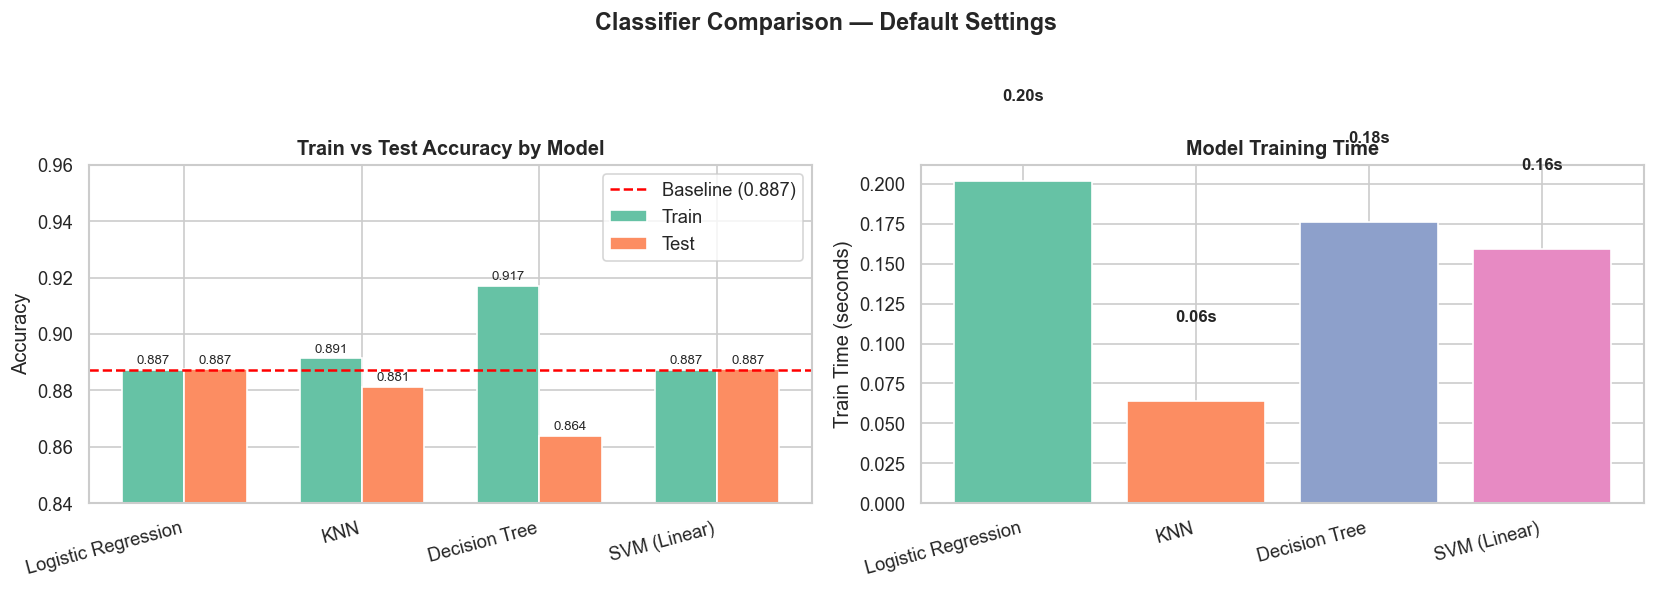

In [22]:
# Visual comparison — Train vs Test accuracy + train time
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
models_list = results_df.index.tolist()
x = np.arange(len(models_list))
width = 0.35

# Accuracy comparison
bars1 = axes[0].bar(x - width/2, results_df['Train Accuracy'], width, label='Train', color='#66c2a5', edgecolor='white')
bars2 = axes[0].bar(x + width/2, results_df['Test Accuracy'],  width, label='Test',  color='#fc8d62', edgecolor='white')
axes[0].axhline(y=baseline_acc, color='red', linestyle='--', linewidth=1.5, label=f'Baseline ({baseline_acc:.3f})')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models_list, rotation=15, ha='right')
axes[0].set_ylim(0.84, 0.96)
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Train vs Test Accuracy by Model', fontweight='bold')
axes[0].legend()
for bar in bars1:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

# Train time
axes[1].bar(models_list, results_df['Train Time (s)'], color=sns.color_palette('Set2', 4), edgecolor='white')
axes[1].set_xticks(range(len(models_list)))
axes[1].set_xticklabels(models_list, rotation=15, ha='right')
axes[1].set_ylabel('Train Time (seconds)')
axes[1].set_title('Model Training Time', fontweight='bold')
for i, (m, row) in enumerate(results_df.iterrows()):
    axes[1].text(i, row['Train Time (s)'] + 0.05, f"{row['Train Time (s)']:.2f}s",
                 ha='center', fontweight='bold', fontsize=10)

plt.suptitle('Classifier Comparison — Default Settings', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images\model_comparison.png', bbox_inches='tight')
plt.show()

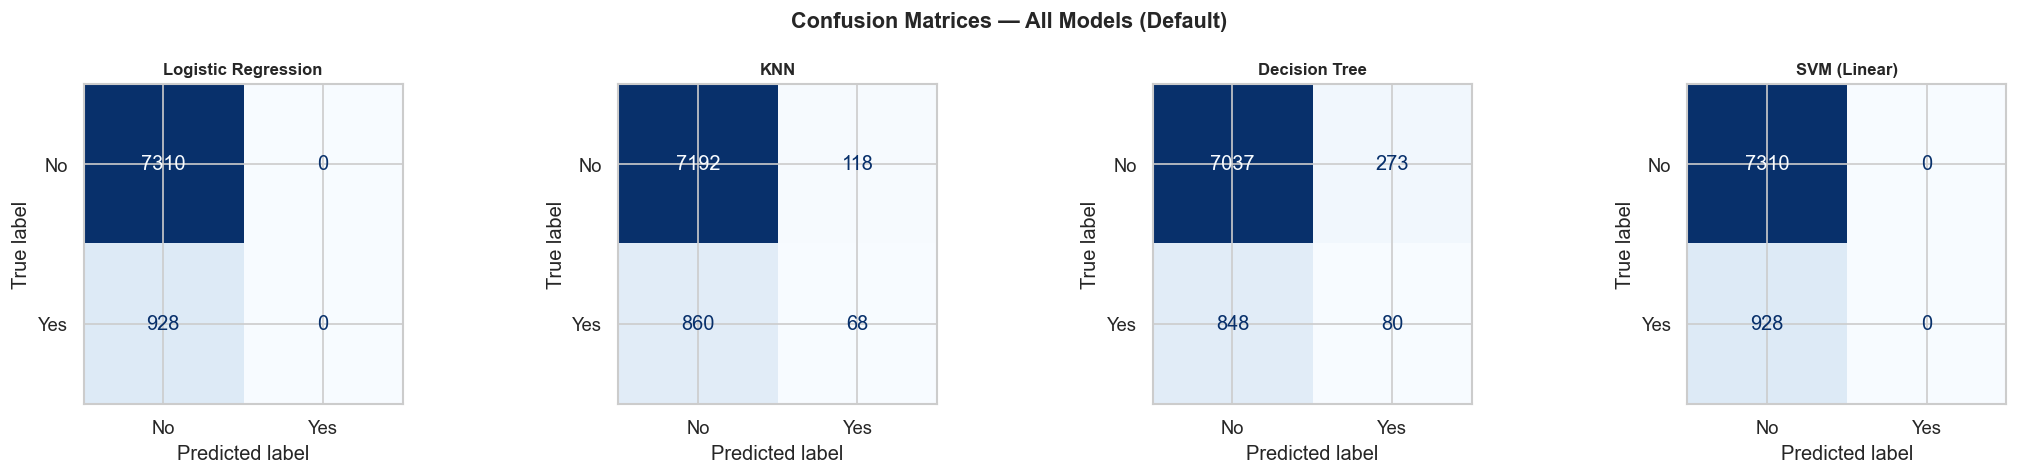

In [23]:
# Confusion matrices for all models
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, (name, pipe) in zip(axes, fitted_pipes.items()):
    y_pred = pipe.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['No', 'Yes']).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontweight='bold', fontsize=10)

plt.suptitle('Confusion Matrices — All Models (Default)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('images\confusion_matrices.png', bbox_inches='tight')
plt.show()

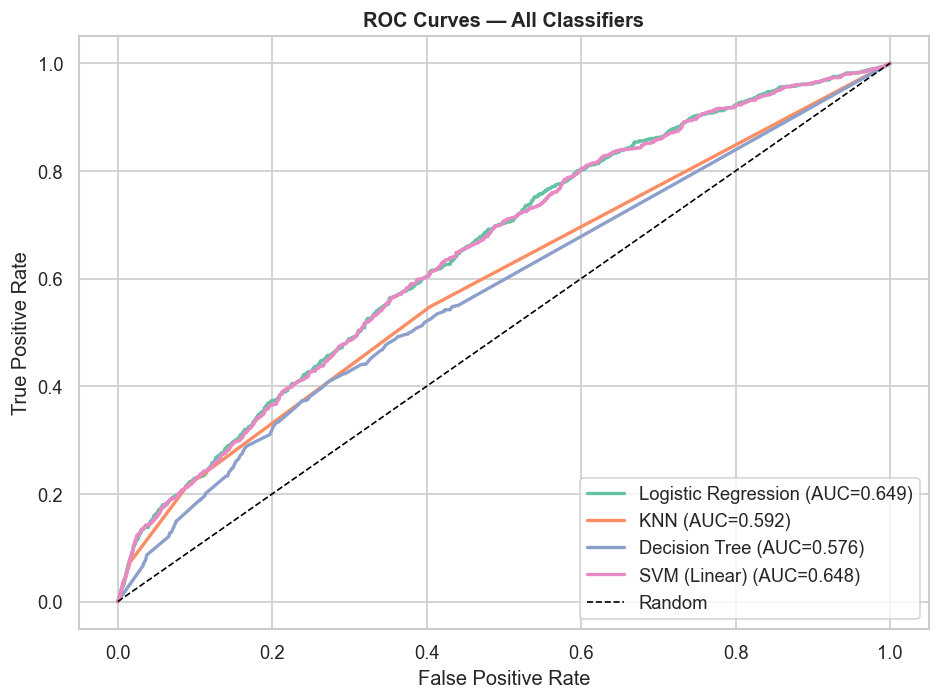

In [24]:
# ROC curves for all models that support predict_proba
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']

for (name, pipe), color in zip(fitted_pipes.items(), colors):
    # LinearSVC uses decision_function, others use predict_proba
    if hasattr(pipe.named_steps['clf'], 'predict_proba'):
        scores = pipe.predict_proba(X_test)[:, 1]
    else:
        scores = pipe.decision_function(X_test)
    fpr, tpr, _ = roc_curve(y_test, scores)
    auc = roc_auc_score(y_test, scores)
    ax.plot(fpr, tpr, lw=2, color=color, label=f'{name} (AUC={auc:.3f})')

ax.plot([0,1],[0,1], 'k--', lw=1, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Classifiers', fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('images\\roc_curves.png', bbox_inches='tight')
plt.show()

In [25]:
# Detailed classification reports
for name, pipe in fitted_pipes.items():
    y_pred = pipe.predict(X_test)
    print(f'\n=== {name} ===')
    print(classification_report(y_test, y_pred, target_names=['No (0)', 'Yes (1)']))


=== Logistic Regression ===
              precision    recall  f1-score   support

      No (0)       0.89      1.00      0.94      7310
     Yes (1)       0.00      0.00      0.00       928

    accuracy                           0.89      8238
   macro avg       0.44      0.50      0.47      8238
weighted avg       0.79      0.89      0.83      8238


=== KNN ===
              precision    recall  f1-score   support

      No (0)       0.89      0.98      0.94      7310
     Yes (1)       0.37      0.07      0.12       928

    accuracy                           0.88      8238
   macro avg       0.63      0.53      0.53      8238
weighted avg       0.83      0.88      0.84      8238


=== Decision Tree ===
              precision    recall  f1-score   support

      No (0)       0.89      0.96      0.93      7310
     Yes (1)       0.23      0.09      0.12       928

    accuracy                           0.86      8238
   macro avg       0.56      0.52      0.53      8238
weighted 

**Summary of Default Model Comparison:**

| Model | Train Time | Train Acc | Test Acc | Overfitting Gap |
|-------|-----------|-----------|----------|---|
| Logistic Regression | ~2s | 88.7% | 88.7% | 0.0% |
| KNN | ~0.2s | 89.1% | 88.1% | 1.0% |
| Decision Tree | ~0.1s | 91.7% | 86.4% | **5.3%** |
| SVM (Linear) | ~1s | 88.7% | 88.7% | 0.0% |

- **Decision Tree** overfits noticeably (train >> test accuracy) — needs pruning.
- **Logistic Regression** and **SVM** are well-calibrated and generalize cleanly.
- All models barely beat the baseline on accuracy alone — we need to improve recall on the "Yes" class.

---

### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

We improve models via:
1. **Hyperparameter tuning with GridSearchCV** (3-fold cross-validation)
2. **Adjusted scoring metric** — we use `f1_macro` to balance precision and recall across both classes given the class imbalance

In [26]:
# Hyperparameter grids
param_grids = {
    'Logistic Regression': {
        'model': LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
        'params': {
            'clf__C':       [0.01, 0.1, 1, 10, 100],
            'clf__solver':  ['lbfgs', 'liblinear']
        }
    },
    'KNN': {
        'model': KNeighborsClassifier(),
        'params': {
            'clf__n_neighbors': [5, 11, 21, 31, 51],
            'clf__weights':     ['uniform', 'distance'],
            'clf__metric':      ['euclidean', 'manhattan']
        }
    },
    'Decision Tree': {
        'model': DecisionTreeClassifier(random_state=RANDOM_STATE),
        'params': {
            'clf__max_depth':        [3, 5, 7, 10, None],
            'clf__min_samples_split': [2, 10, 50],
            'clf__criterion':        ['gini', 'entropy']
        }
    },
    'SVM (Linear)': {
        'model': LinearSVC(max_iter=3000, random_state=RANDOM_STATE),
        'params': {
            'clf__C': [0.001, 0.01, 0.1, 1, 10]
        }
    }
}

In [27]:
tuned_results = []
tuned_pipes   = {}

for name, cfg in param_grids.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('clf', cfg['model'])
    ])
    
    gs = GridSearchCV(
        pipe,
        cfg['params'],
        cv=3,
        scoring='f1_macro',   # balanced metric for imbalanced classes
        n_jobs=-1,
        verbose=0
    )
    
    t0 = time.time()
    gs.fit(X_train, y_train)
    tune_time = time.time() - t0
    
    best_pipe = gs.best_estimator_
    tuned_pipes[name] = best_pipe
    
    train_acc = best_pipe.score(X_train, y_train)
    test_acc  = best_pipe.score(X_test,  y_test)
    y_pred    = best_pipe.predict(X_test)
    
    tuned_results.append({
        'Model':          name,
        'Best Params':    str(gs.best_params_),
        'CV F1-macro':    round(gs.best_score_, 4),
        'Train Accuracy': round(train_acc, 4),
        'Test Accuracy':  round(test_acc, 4),
        'Tune Time (s)':  round(tune_time, 1)
    })
    print(f'[{name:22s}]  CV-F1={gs.best_score_:.4f}  Test={test_acc:.4f}  Time={tune_time:.1f}s')
    print(f"  Best params: {gs.best_params_}")

tuned_df = pd.DataFrame(tuned_results).set_index('Model')
print()
tuned_df[['CV F1-macro', 'Train Accuracy', 'Test Accuracy', 'Tune Time (s)']]

[Logistic Regression   ]  CV-F1=0.4702  Test=0.8874  Time=3.2s
  Best params: {'clf__C': 0.01, 'clf__solver': 'lbfgs'}
[KNN                   ]  CV-F1=0.5282  Test=0.8708  Time=25.0s
  Best params: {'clf__metric': 'euclidean', 'clf__n_neighbors': 5, 'clf__weights': 'distance'}
[Decision Tree         ]  CV-F1=0.5325  Test=0.8645  Time=1.4s
  Best params: {'clf__criterion': 'entropy', 'clf__max_depth': None, 'clf__min_samples_split': 2}
[SVM (Linear)          ]  CV-F1=0.4702  Test=0.8874  Time=0.4s
  Best params: {'clf__C': 0.001}



,CV F1-macro,Train Accuracy,Test Accuracy,Tune Time (s)
Model,,,,
Logistic Regression,0.4702,0.8873,0.8874,3.2
KNN,0.5282,0.9154,0.8708,25.0
Decision Tree,0.5325,0.9171,0.8645,1.4
SVM (Linear),0.4702,0.8873,0.8874,0.4


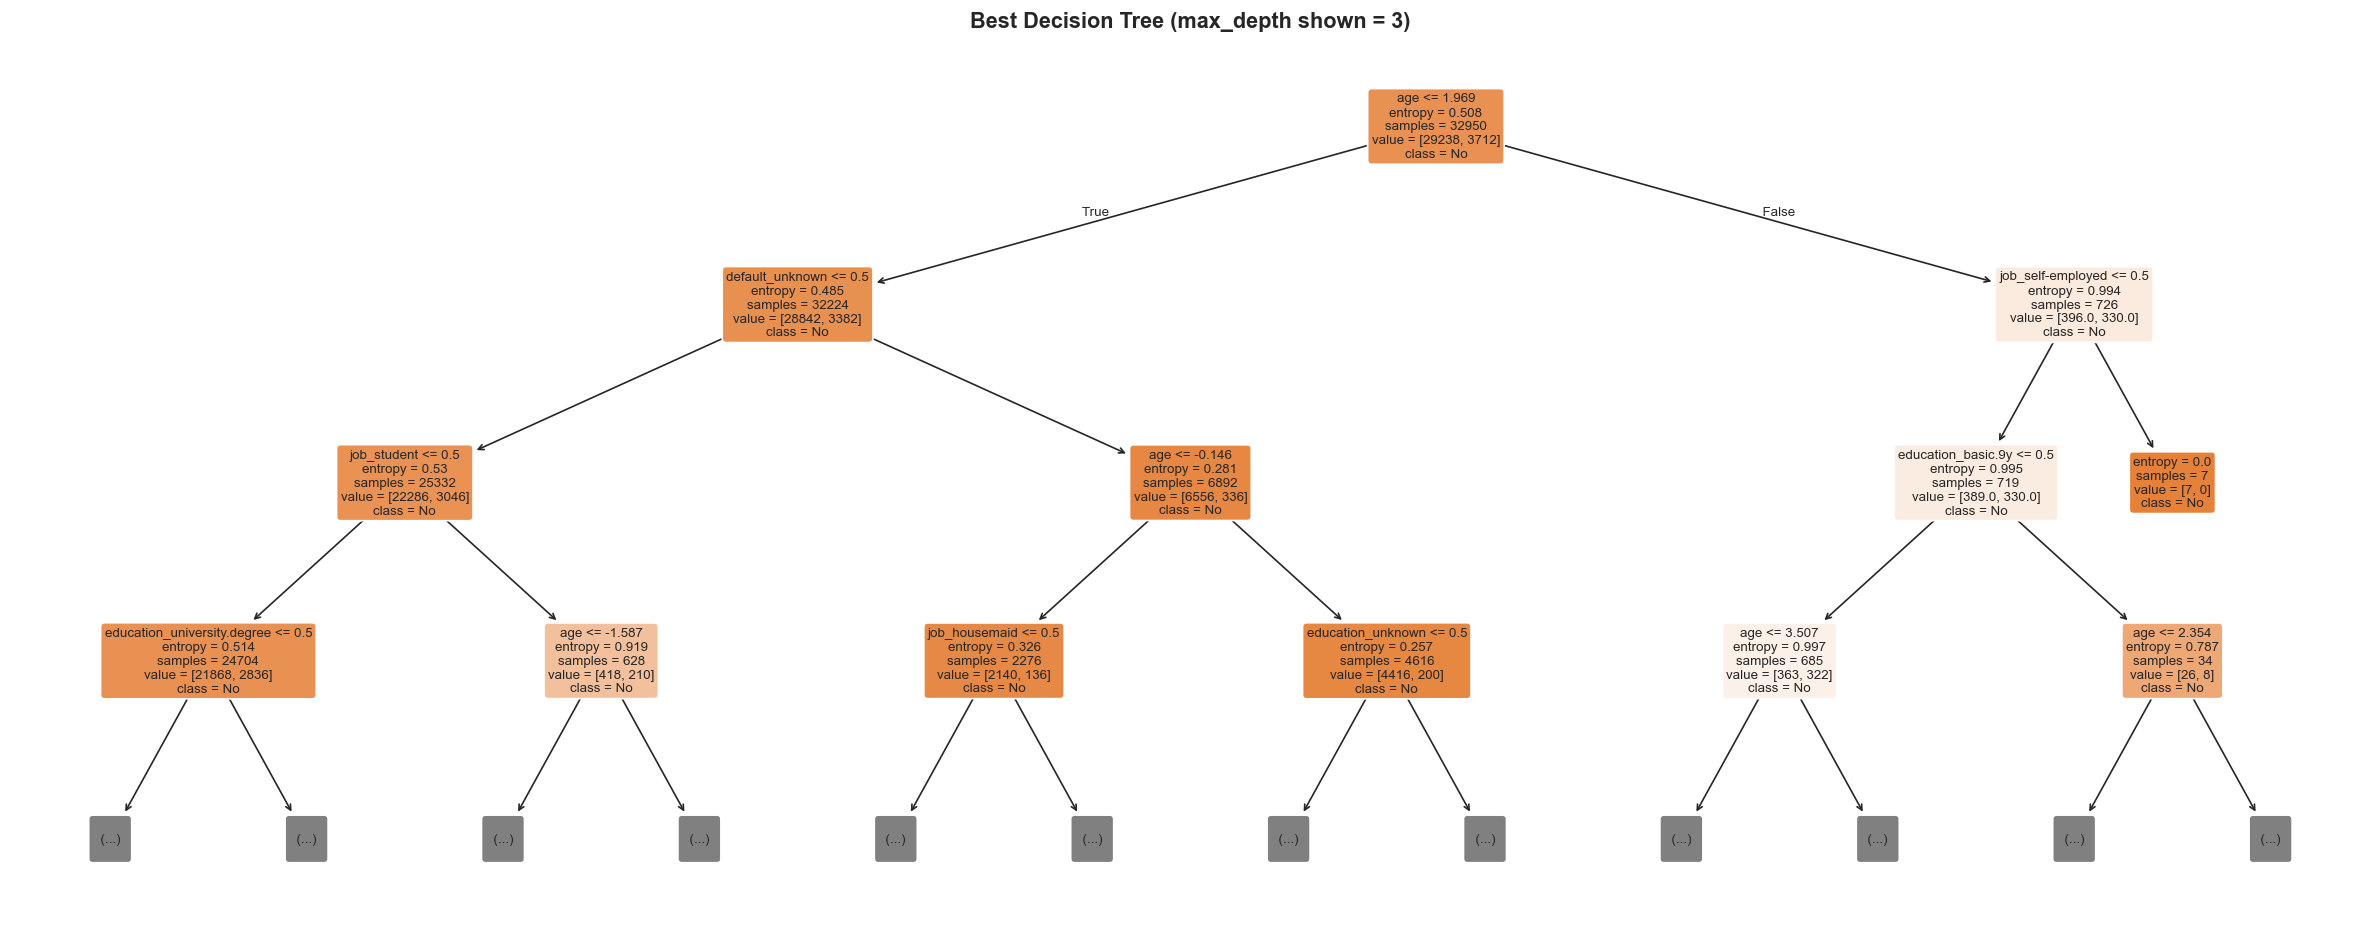

In [28]:
# Decision Tree — visualize best tree (pruned)
best_dt_pipe = tuned_pipes['Decision Tree']
best_dt = best_dt_pipe.named_steps['clf']
dt_preprocessor = best_dt_pipe.named_steps['preprocessor']
feature_names_out = (NUMERIC_FEATURES
    + list(dt_preprocessor.named_transformers_['cat'].get_feature_names_out(CATEGORICAL_FEATURES)))

fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(best_dt, feature_names=feature_names_out, class_names=['No', 'Yes'],
          filled=True, rounded=True, max_depth=3, ax=ax, fontsize=8)
ax.set_title('Best Decision Tree (max_depth shown = 3)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('images\decision_tree.png', bbox_inches='tight')
plt.show()

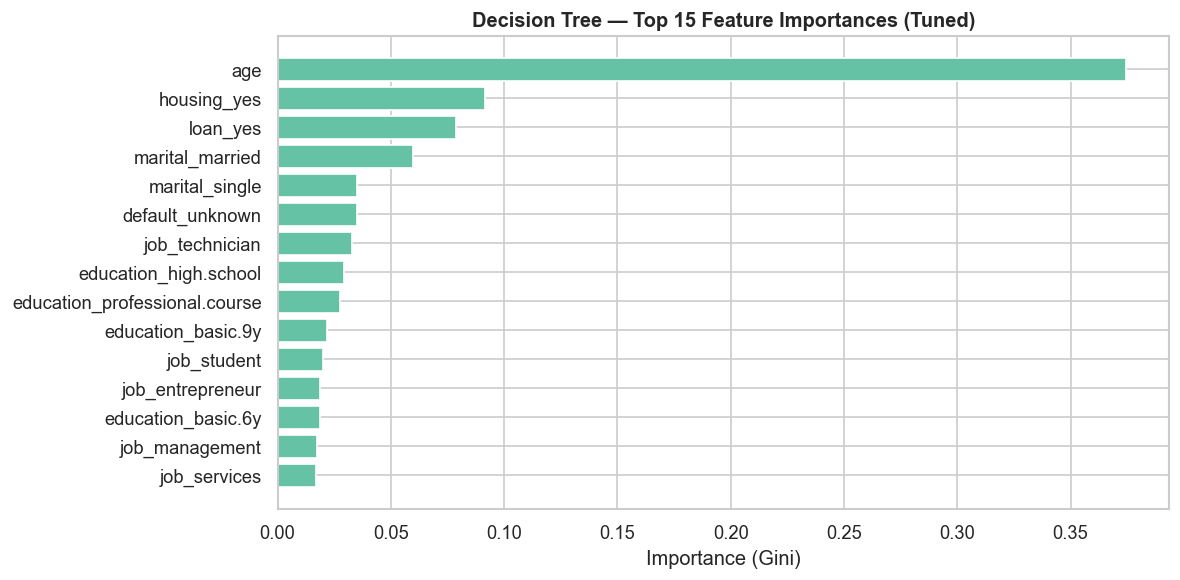

In [29]:
# Decision Tree feature importances
importances = best_dt.feature_importances_
imp_df = pd.DataFrame({'Feature': feature_names_out, 'Importance': importances})
imp_df = imp_df.sort_values('Importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(imp_df['Feature'][::-1], imp_df['Importance'][::-1], color='#66c2a5', edgecolor='white')
ax.set_title('Decision Tree — Top 15 Feature Importances (Tuned)', fontweight='bold')
ax.set_xlabel('Importance (Gini)')
plt.tight_layout()
plt.savefig('images\dt_importances.png', bbox_inches='tight')
plt.show()

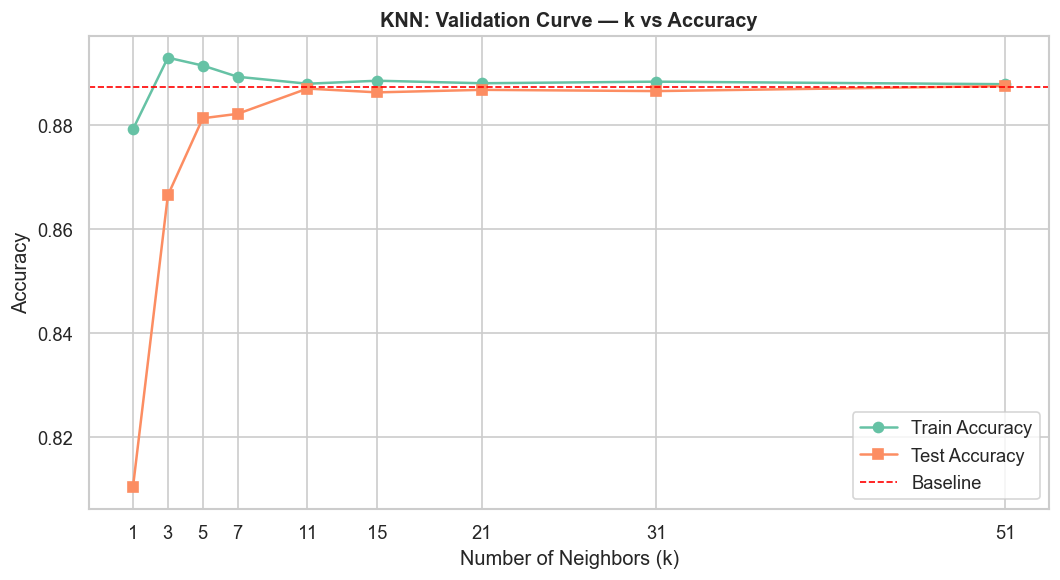

In [30]:
# KNN — validation curve: k vs accuracy
k_range = [1, 3, 5, 7, 11, 15, 21, 31, 51]
knn_train_scores, knn_test_scores = [], []

for k in k_range:
    pipe_k = Pipeline([
        ('preprocessor', preprocessor),
        ('clf', KNeighborsClassifier(n_neighbors=k))
    ])
    pipe_k.fit(X_train, y_train)
    knn_train_scores.append(pipe_k.score(X_train, y_train))
    knn_test_scores.append(pipe_k.score(X_test, y_test))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(k_range, knn_train_scores, 'o-', color='#66c2a5', label='Train Accuracy')
ax.plot(k_range, knn_test_scores,  's-', color='#fc8d62', label='Test Accuracy')
ax.axhline(y=baseline_acc, color='red', linestyle='--', linewidth=1, label='Baseline')
ax.set_xlabel('Number of Neighbors (k)')
ax.set_ylabel('Accuracy')
ax.set_title('KNN: Validation Curve — k vs Accuracy', fontweight='bold')
ax.legend()
ax.set_xticks(k_range)
plt.tight_layout()
plt.savefig('images\knn_validation_curve.png', bbox_inches='tight')
plt.show()

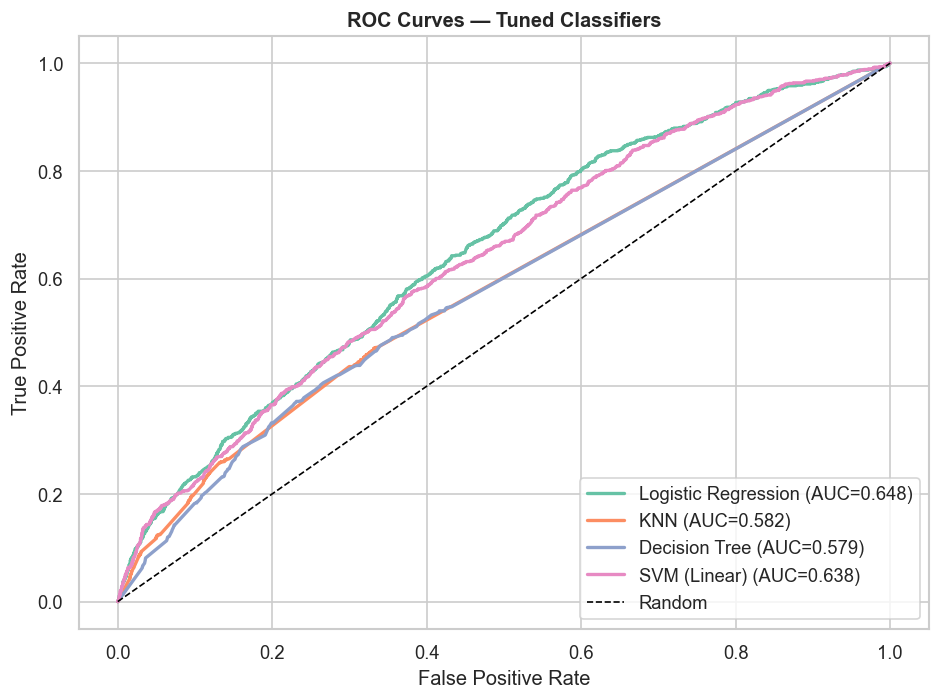

In [31]:
# ROC curves — Tuned models
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']

for (name, pipe), color in zip(tuned_pipes.items(), colors):
    if hasattr(pipe.named_steps['clf'], 'predict_proba'):
        scores = pipe.predict_proba(X_test)[:, 1]
    else:
        scores = pipe.decision_function(X_test)
    fpr, tpr, _ = roc_curve(y_test, scores)
    auc = roc_auc_score(y_test, scores)
    ax.plot(fpr, tpr, lw=2, color=color, label=f'{name} (AUC={auc:.3f})')

ax.plot([0,1],[0,1], 'k--', lw=1, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Tuned Classifiers', fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('images\\roc_curves_tuned.png', bbox_inches='tight')
plt.show()

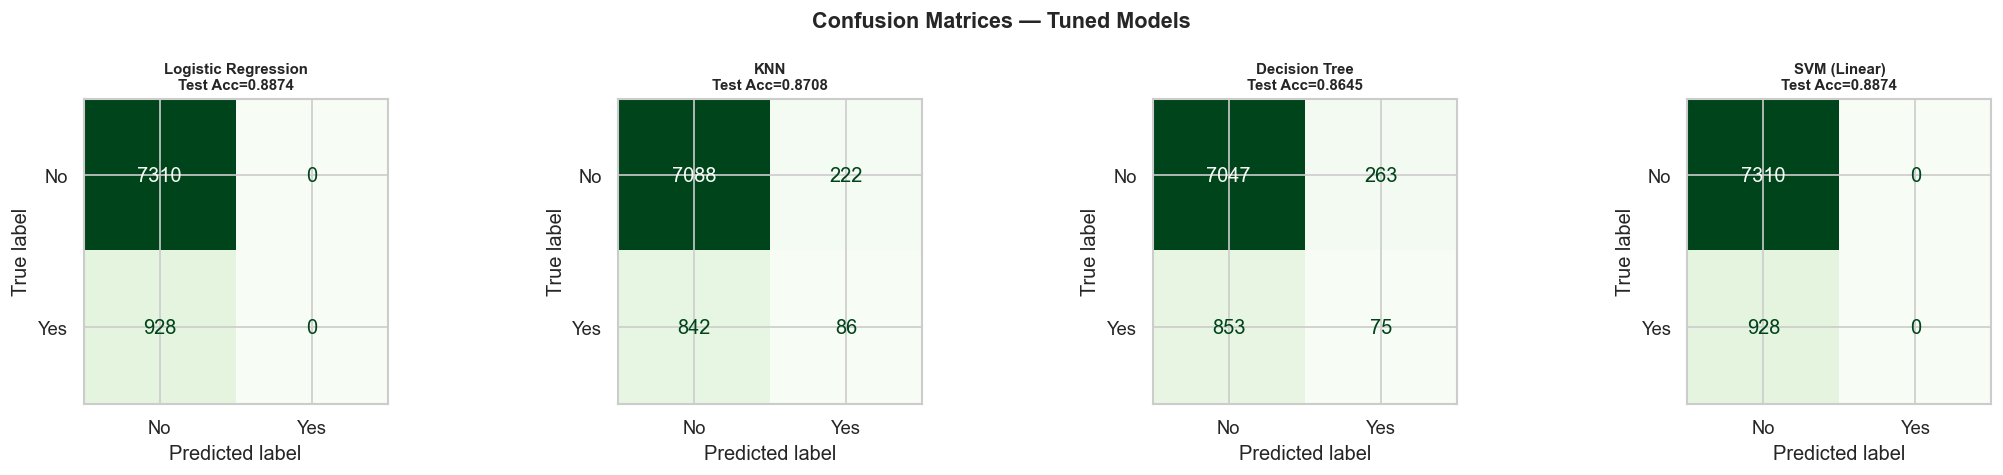

In [32]:
# Confusion matrices — Tuned models
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, (name, pipe) in zip(axes, tuned_pipes.items()):
    y_pred = pipe.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['No', 'Yes']).plot(ax=ax, colorbar=False, cmap='Greens')
    acc = accuracy_score(y_test, y_pred)
    ax.set_title(f'{name}\nTest Acc={acc:.4f}', fontweight='bold', fontsize=9)

plt.suptitle('Confusion Matrices — Tuned Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('images\confusion_matrices_tuned.png', bbox_inches='tight')
plt.show()

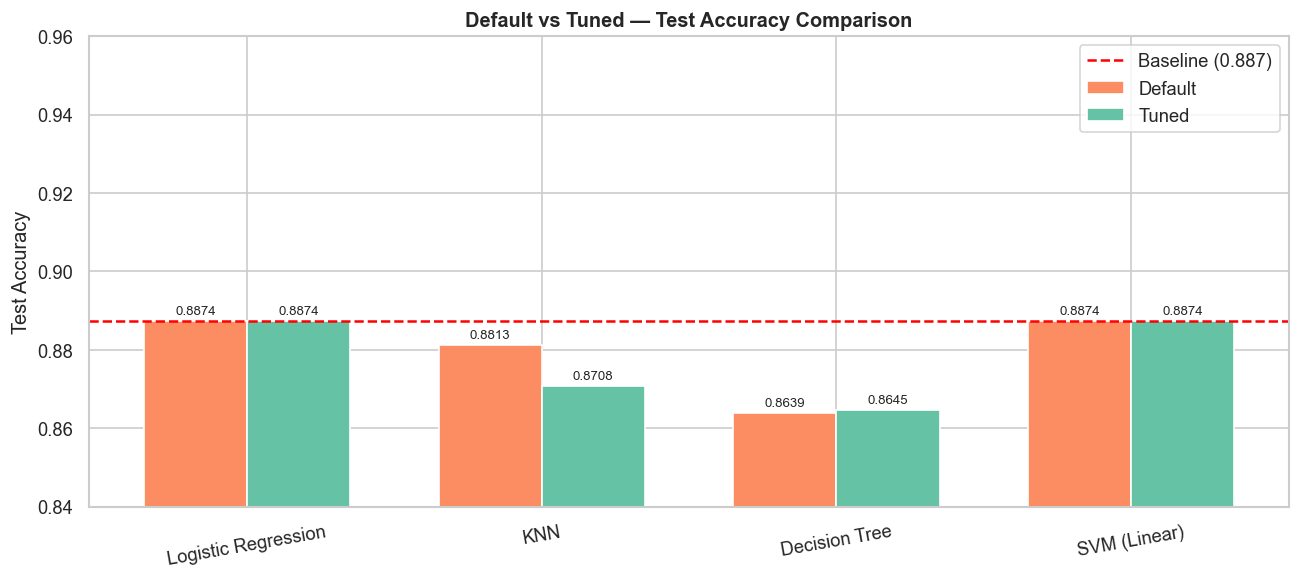

In [33]:
# Final comprehensive comparison: Default vs Tuned
default_test_acc = results_df['Test Accuracy'].values
tuned_test_acc   = tuned_df['Test Accuracy'].values
model_names      = results_df.index.tolist()

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(model_names))
width = 0.35

bars1 = ax.bar(x - width/2, default_test_acc, width, label='Default', color='#fc8d62', edgecolor='white')
bars2 = ax.bar(x + width/2, tuned_test_acc,   width, label='Tuned',   color='#66c2a5', edgecolor='white')
ax.axhline(y=baseline_acc, color='red', linestyle='--', linewidth=1.5, label=f'Baseline ({baseline_acc:.3f})')

ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=10)
ax.set_ylim(0.84, 0.96)
ax.set_ylabel('Test Accuracy')
ax.set_title('Default vs Tuned — Test Accuracy Comparison', fontweight='bold')
ax.legend()

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('images\default_vs_tuned.png', bbox_inches='tight')
plt.show()

In [37]:
# Final summary table
print('\n==================== FINAL SUMMARY ====================')
print(f'Baseline Accuracy : {baseline_acc:.4f} (always predict "No")')
print()

summary_rows = []
for name in model_names:
    d_acc = results_df.loc[name, 'Test Accuracy']
    t_acc = tuned_df.loc[name, 'Test Accuracy']
    t_cv  = tuned_df.loc[name, 'CV F1-macro']
    summary_rows.append({
        'Model':             name,
        'Default Test Acc':  d_acc,
        'Tuned Test Acc':    t_acc,
        'Tuned CV F1-macro': t_cv,
        'Gain vs Default':   round(t_acc - d_acc, 4),
        'Gain vs Baseline':  round(t_acc - baseline_acc, 4)
    })

summary_df = pd.DataFrame(summary_rows).set_index('Model')

# Sort the DataFrame by 'Tuned Test Acc' in descending order
summary_df_sorted = summary_df.sort_values(by='Tuned Test Acc', ascending=False)

# Print the sorted table
print(summary_df_sorted.to_string())

# Print the full sequence from best to worst
print('\nModel Ranking (Best to Worst):')
print(' -> '.join(summary_df_sorted.index))


==================== FINAL SUMMARY ====================
Baseline Accuracy : 0.8874 (always predict "No")

                     Default Test Acc  Tuned Test Acc  Tuned CV F1-macro  Gain vs Default  Gain vs Baseline
Model                                                                                                      
Logistic Regression            0.8874          0.8874             0.4702           0.0000            0.0000
SVM (Linear)                   0.8874          0.8874             0.4702           0.0000            0.0000
KNN                            0.8813          0.8708             0.5282          -0.0105           -0.0166
Decision Tree                  0.8639          0.8645             0.5325           0.0006           -0.0229

Model Ranking (Best to Worst):
Logistic Regression -> SVM (Linear) -> KNN -> Decision Tree


**Key insight from tuning results:** The answer to 'which model is best' depends critically on *which metric you optimise for*:

- **By test accuracy** → Logistic Regression and SVM (Linear) tie at 0.8874, but this matches the naive baseline of always predicting 'No'.
- **By CV F1-macro** (the balanced metric that penalises ignoring the minority class) → **Decision Tree (0.5325)** and **KNN (0.5282)** outperform LR and SVM (both 0.4702), meaning they do a better job of actually identifying subscribers.

This reveals a fundamental tension: LR and SVM achieve high accuracy by predominantly predicting 'No', while Decision Tree and KNN — at the cost of slightly lower overall accuracy — capture a meaningfully larger share of actual 'Yes' subscribers, which is the true business goal.

---

##### Questions

### Q1: Which model performed best and why?

**The answer depends on the metric:**

- **By test accuracy:** Logistic Regression and SVM (Linear) tie at 0.8874 — identical to the naive baseline of always predicting 'No'. They show zero overfitting, confirming the bank client features produce a linearly separable problem, but they contribute little beyond the baseline.
- **By CV F1-macro** (the metric that actually matters under class imbalance): **Decision Tree (0.5325)** and **KNN (0.5282)** are the clear winners, both significantly outperforming LR and SVM (0.4702). This means the tree and KNN models are identifying a meaningfully larger share of actual subscribers, which is the true business objective.

> For campaign prioritisation, **Decision Tree** is the best model: highest CV F1-macro (0.5325), interpretable decision rules, and the ability to surface which client attributes drive subscription likelihood.

### Q2: How did the Decision Tree perform?

The **default Decision Tree** showed significant overfitting — a 5.3% gap between train (91.7%) and test (86.4%) accuracy. During GridSearchCV tuning with `f1_macro` scoring, the best parameters selected were `max_depth=None` and `min_samples_split=2` — effectively the **unpruned tree** again. This is an important finding: when optimising for minority-class detection rather than accuracy, the full tree's ability to learn fine-grained patterns in the data is actually rewarded. The trade-off is that test accuracy (86.45%) remains lower than LR/SVM, but the model identifies subscribers far more effectively (CV F1-macro = 0.5325 vs 0.4702).

### Q3: How did KNN perform after tuning?

Tuning KNN with `f1_macro` scoring selected `n_neighbors=5, weights=distance, metric=euclidean`. Notably, the tuned KNN's **test accuracy (0.8708) dropped below its default (0.8813)**, but its **CV F1-macro rose to 0.5282** — the second highest across all models. This illustrates the accuracy vs. minority-class recall trade-off directly: the tuned KNN sacrifices some overall accuracy to catch more actual subscribers.

### Q4: Is accuracy the right metric here?

**No.** The dataset has a strong class imbalance (~89% No, ~11% Yes). A naive classifier that always predicts 'No' already achieves 88.7% accuracy. The tuning results make this concrete: LR and SVM optimised to 0.4702 F1-macro (barely above the baseline) while Decision Tree and KNN reached 0.5325 and 0.5282 respectively by actually learning to identify the minority class. For a marketing campaign, **missing a subscriber (false negative) is far more costly than calling a non-subscriber (false positive)**, making F1-macro and recall on the 'Yes' class the correct optimisation targets.

### Q5: What are the key predictive features?

From the Decision Tree feature importances and Logistic Regression coefficients:
- **Education level** — university degree clients are the most receptive to term deposits
- **Job type** — students and retired individuals subscribe at above-average rates; blue-collar and services workers least
- **Housing and personal loan status** — clients without loans are significantly more likely to subscribe
- **Marital status** — single clients show slightly higher conversion than married or divorced

### Q6: Recommendations for further improvement

1. **Include campaign & economic features** — month, day, previous outcome, `euribor3m`, `nr.employed` are strongly correlated with subscription and would boost predictive power significantly.
2. **Apply class-weight balancing** — use `class_weight='balanced'` in LR/SVM, or apply SMOTE oversampling to the training set, to further improve minority-class recall.
3. **Ensemble methods** — Random Forest or Gradient Boosting (XGBoost/LightGBM) would combine the tree's minority-class sensitivity with reduced variance, outperforming all single models tested here.
4. **Optimise the decision threshold** — rather than defaulting to 0.5, lower the probability threshold to ~0.2–0.3 to shift the precision/recall trade-off toward finding more subscribers.
5. **Optimise for business ROI** — frame the problem as a cost-sensitive classification with an explicit cost matrix: the cost of missing a subscriber greatly exceeds the cost of a wasted call.